# Analyzing the dataset 

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('../data/HomeC.csv')
df.head()

C:\Users\Irina\AppData\Local\Temp\ipykernel_9660\585423653.py:1: DtypeWarning: Columns (0: time, 1: cloudCover) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/HomeC.csv')


,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
0,1451624400,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1,1451624401,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2,1451624402,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
3,1451624403,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
4,1451624404,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [32]:
df.tail()

,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
503906,1452128306,1.599333,0.003233,1.599333,0.000050,0.104017,0.625033,0.041750,0.005233,0.008433,...,8.74,Light Rain,29.45,1011.49,6.72,0.31,186.0,0.0101,31.27,0.51
503907,1452128307,1.924267,0.003217,1.924267,0.000033,0.422383,0.637733,0.042033,0.004983,0.008467,...,8.74,Light Rain,29.45,1011.49,6.72,0.31,186.0,0.0101,31.27,0.51
503908,1452128308,1.978200,0.003217,1.978200,0.000050,0.495667,0.620367,0.042100,0.005333,0.008233,...,8.74,Light Rain,29.45,1011.49,6.72,0.31,186.0,0.0101,31.27,0.51
503909,1452128309,1.990950,0.003233,1.990950,0.000050,0.494700,0.634133,0.042100,0.004917,0.008133,...,8.74,Light Rain,29.45,1011.49,6.72,0.31,186.0,0.0101,31.27,0.51
503910,\,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Last row is invalid

In [33]:
df = df[0:-1]

In [34]:
df.columns = [col.replace(' [kW]', '') for col in df.columns]
df['Furnace'] = df[['Furnace 1', 'Furnace 2']].sum(axis=1)

df['Kitchen'] = df[['Kitchen 12', 'Kitchen 14', 'Kitchen 38']].mean(axis=1)
    
df = df.drop(['Furnace 1', 'Furnace 2', 'Kitchen 12', 'Kitchen 14', 'Kitchen 38'], axis=1)

In [35]:
print("Unique values in cloudCover column:")
print(df['cloudCover'].unique())

# Number of invalid (textual) entries in cloudCover
bad_rows = df[df['cloudCover'] == 'cloudCover'].shape[0]
print(f"\nNumber of invalid (textual) entries in cloudCover: {bad_rows}")


Unique values in cloudCover column:
['cloudCover' '0.75' '0' '1' '0.31' '0.44' '0.13' '0.19' '0.25' '0.16'
 '0.21' '0.15' '0.14' '0.27' '0.28' '0.17' '0.05' '0.1' '0.26' '0.29'
 '0.11' '0.09' '0.12' '0.06' '0.02' '0.08' '0.04' '0.35' '0.22' '0.23'
 '0.54' '0.39' '0.03' '0.07' '0.76' '0.62' '0.18' '0.79' '0.48' '0.24'
 '0.57' 0.24 1.0 0.31 0.28 0.15 0.41 0.1 0.12 0.08 0.09 0.19 0.04 0.05
 0.29 0.27 0.35 0.18 0.06 0.03 0.11 0.14 0.25 0.78 0.0 0.16 0.21 0.23 0.17
 0.75 0.26 0.2 0.76 0.13 0.77 0.46 0.07 0.55 0.02 0.01 0.51 0.47 0.5 0.4
 0.3 0.22 0.43 0.33 0.6 0.68 0.66 0.45 0.34 0.52 0.67 0.48 0.49 0.39 0.37
 0.62 0.36 0.79 0.61 0.38 0.42 0.53 0.63 0.44 0.54 0.32 0.56 0.58 0.72
 0.57 0.73 0.71 0.64 0.59]

Number of invalid (textual) entries in cloudCover: 58


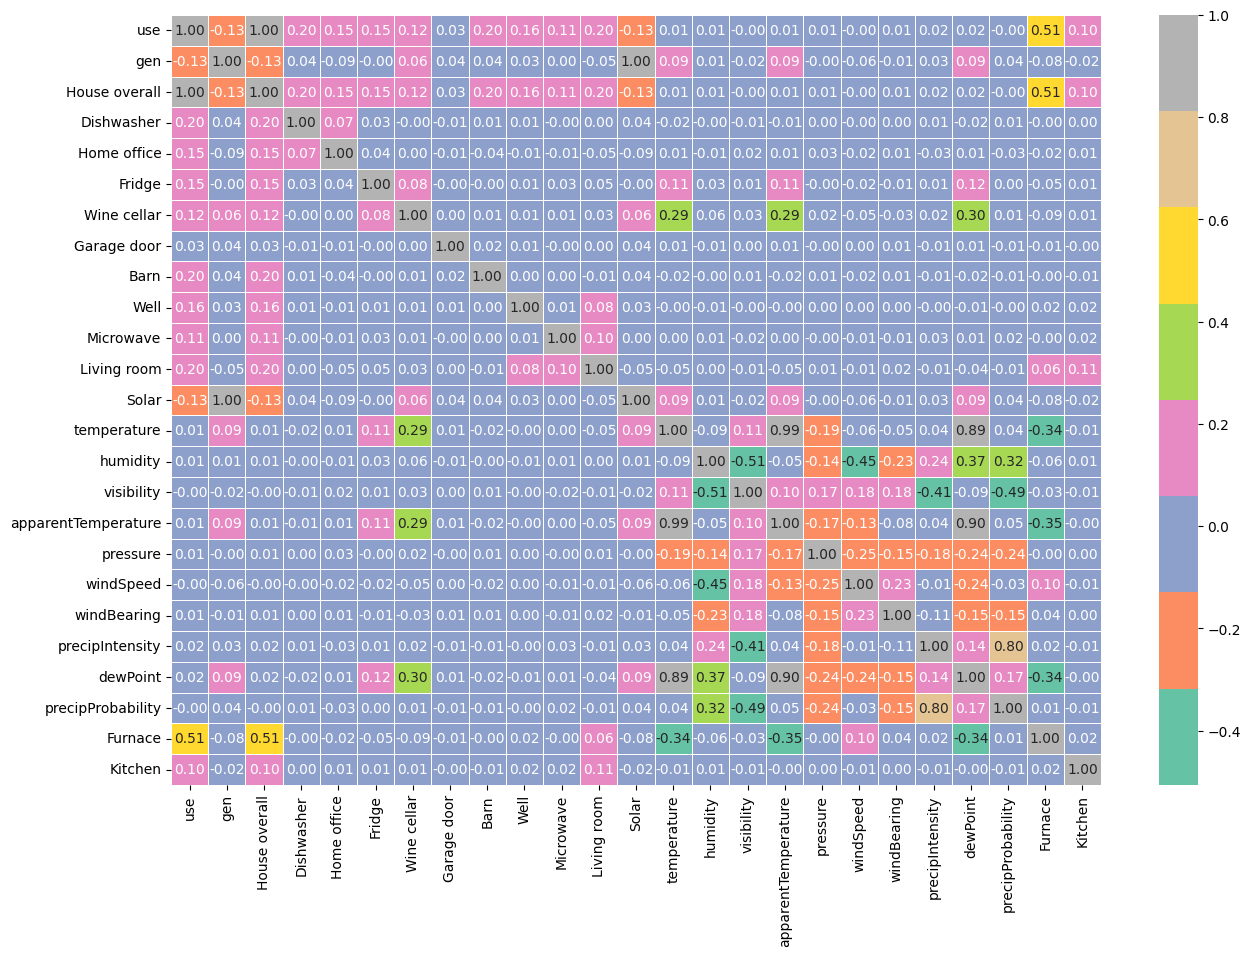

In [36]:
numerical_features = df.select_dtypes(include=[np.number])

correlation_matrix = df[numerical_features.columns].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Set2",   
    fmt=".2f",
    linewidths=.5
)
plt.show()

Conclusion: 'Solar' and 'gen' are the same, as well as 'House overall' and 'use'

In [37]:
print(df['icon'].unique())
print(df['summary'].unique())

<StringArray>
[        'clear-night', 'partly-cloudy-night',           'clear-day',
              'cloudy',   'partly-cloudy-day',                'rain',
                'snow',                'wind',                 'fog']
Length: 9, dtype: str
<StringArray>
[                   'Clear',            'Mostly Cloudy',
                 'Overcast',            'Partly Cloudy',
                  'Drizzle',               'Light Rain',
                     'Rain',               'Light Snow',
                 'Flurries',                   'Breezy',
                     'Snow',          'Rain and Breezy',
                    'Foggy', 'Breezy and Mostly Cloudy',
 'Breezy and Partly Cloudy',      'Flurries and Breezy',
                      'Dry',               'Heavy Snow']
Length: 18, dtype: str


Mostly the same, 'summary' is more descriptive